# 서울시 119 구급 관련 공공 API 수집 (v2)

**목적** : 자치구별 월간 구급 출동·이송 건수 예측 모델용 학습 데이터 수집 + 실시간 응급실 병상 현황(참고용) 수집

| 구분 | 출처 | 저장 파일 |
|---|---|---|
| 월별 출동·이송 | 소방청 구급통계 API | `outputs/ambulance_prophet_<시작>_<끝>_api.csv`, `ml_data/ambulance_monthly.csv` |
| 실시간 응급실 병상 | 국립중앙의료원 API + 안전데이터포털(DSSP-IF-00242, 10288) | `outputs/realtime_er_beds.csv` |
| 자치구별 병상수(연도, 참고용) | 안전데이터포털(DSSP-IF-00606) | `ml_data/gu_beds_yearly.csv` |

**v2 주요 변경**
- 쿼터 소진 감지 누락 수정 (XML 오류 응답, 넓은 except)
- 응급실 병상 음수값 = 과밀 상태로 해석 변경
- 오래된 병상 정보(갱신 지연) 표시
- 안전데이터 API 페이지 반복 수집 + 로컬 CSV 대체
- 이어받기 파일명 고정, 불완전한 월 저장 방지
- 예측 모델용 `ml_data` 저장 + 누락 월 확인

## 0. 환경 설정

In [1]:
import os
import re
import time
import glob
import warnings
import requests
import urllib3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import xml.etree.ElementTree as ET
from dotenv import load_dotenv

try:
    from IPython.display import display
except ImportError:          # .py로 실행할 때 대비
    display = print

warnings.filterwarnings(action="ignore")
urllib3.disable_warnings()   # 안전데이터포털 verify=False 경고 숨김

load_dotenv(override=True)                    # .env 수정 후 다시 실행해도 새 값 반영
SERVICE_KEY = os.getenv("DATA_GO_KR_KEY")       # 공공데이터포털 키

# 안전데이터포털 : API마다 서비스키가 다름 -> API 번호별로 .env 변수 이름 지정
SAFETY_APIS = {
    "DSSP-IF-00242": {"env": "SAFETY_KEY_00242", "name": "국립중앙의료원_의료기관_실시간_병상정보", "params": {}},
    "DSSP-IF-10288": {"env": "SAFETY_KEY_10288", "name": "중앙응급의료센터의료기관", "params": {}},
    "DSSP-IF-00606": {"env": "SAFETY_KEY_00606", "name": "행정안전부_병상수", "params": {}},
}
# "params" : 명세서의 필수 요청변수가 더 있으면 여기에 추가 (예: {"crtrYr": "2025"})
for info in SAFETY_APIS.values():
    info["key"] = os.getenv(info["env"])

# 키 확인 (앞 4자리만 표시)
def mask(key):
    return key[:4] + "****" if key else "없음"

print(f"DATA_GO_KR_KEY   : {mask(SERVICE_KEY)}")
for api_id, info in SAFETY_APIS.items():
    print(f"{info['env']} : {mask(info['key'])}  ({api_id} {info['name']})")

# 경로 (팀원 환경에 맞게 BASE_DIR만 수정)
BASE_DIR = "C:/ai/source/09_Project/cheolhyeon_jo"
SRC_DIR = f"{BASE_DIR}/data"
OUT_DIR = f"{BASE_DIR}/outputs"          # 새로 수집한 파일 저장 폴더
ML_DIR = f"{BASE_DIR}/ml_data"          # 모델 학습용 통합 데이터 폴더

# 기존 수집 파일을 찾을 폴더 목록 (이어받기용, 필요하면 추가)
SEARCH_DIRS = [OUT_DIR, f"{BASE_DIR}/outputs"]
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(ML_DIR, exist_ok=True)

REQUEST_INTERVAL = 1.0   # 요청 간격(초), 429 오류가 잦으면 늘리기
STALE_HOURS = 24         # 병상 정보가 이 시간보다 오래되면 '정보 없음' 처리

DATA_GO_KR_KEY   : 3cd0****
SAFETY_KEY_00242 : G6QX****  (DSSP-IF-00242 국립중앙의료원_의료기관_실시간_병상정보)
SAFETY_KEY_10288 : 55P5****  (DSSP-IF-10288 중앙응급의료센터의료기관)
SAFETY_KEY_00606 : DJUT****  (DSSP-IF-00606 행정안전부_병상수)


### 0-1. 공통 요청 함수 + 오류 처리

**작동 원리**
- 지수 백오프 재시도 (2초 → 4초 → 8초 …)
- 네트워크 끊김·타임아웃 재시도
- XML 오류 응답 해석 (HTTP 200이어도 본문에 오류 코드 존재)
- 쿼터 소진 전용 예외 `RateLimitExhausted`

In [2]:
class RateLimitExhausted(Exception):
    """일일 사용량(쿼터) 소진 시 발생"""
    pass


def request_get_with_retry(url, params, max_retries=5, base_delay=2.0, timeout=10, verify=True):
    """
    - 429, 5xx, 네트워크 오류 : 대기 후 재시도
    - 그 외 4xx : 재시도해도 소용없으므로 즉시 예외
    """
    last_status = None

    for attempt in range(max_retries):
        wait = base_delay * (2 ** attempt)
        try:
            response = requests.get(url, params=params, timeout=timeout, verify=verify)
        except (requests.ConnectionError, requests.Timeout) as e:
            print(f"  [재시도 {attempt+1}/{max_retries}] 네트워크 오류 -> {wait:.1f}초 대기 ({type(e).__name__})")
            time.sleep(wait)
            continue

        if response.status_code == 200:
            return response
        last_status = response.status_code

        if response.status_code == 429 or 500 <= response.status_code < 600:
            wait = float(response.headers.get("Retry-After", wait))
            print(f"  [재시도 {attempt+1}/{max_retries}] 오류 코드 {response.status_code} -> {wait:.1f}초 대기")
            time.sleep(wait)
            continue

        response.raise_for_status()

    if last_status == 429:
        raise RateLimitExhausted("당일 트래픽(일일 쿼터)을 모두 소진했습니다.")
    raise RuntimeError(f"{max_retries}회 재시도 실패 (마지막 상태 코드: {last_status})")


def parse_xml_items(xml_text):
    """XML 응답 -> (딕셔너리 리스트, totalCount)"""
    root = ET.fromstring(xml_text)

    # 공공데이터포털 게이트웨이 오류 (키 오류, 쿼터 초과 등)
    reason = root.findtext(".//returnReasonCode")
    if reason and reason != "00":
        msg = root.findtext(".//returnAuthMsg")
        if reason == "22" or "LIMITED" in str(msg):
            raise RateLimitExhausted(msg)
        raise RuntimeError(f"API 오류 {reason}: {msg}")

    # 서비스 자체 오류
    result_code = root.findtext(".//resultCode")
    if result_code not in (None, "00"):
        msg = root.findtext(".//resultMsg")
        if result_code == "22" or "LIMITED" in str(msg):
            raise RateLimitExhausted(msg)
        raise RuntimeError(f"API 오류 {result_code}: {msg}")

    rows = [{child.tag: child.text for child in item} for item in root.findall(".//item")]
    total = int(root.findtext(".//totalCount", default=0) or 0)
    return rows, total

### 0-2. 소방서 → 자치구 매핑

**작동 원리**
- 정규표현식으로 관할구역에서 `○○구` 추출
- 소방서별 최빈 자치구 선택
- 25개 자치구 누락·중복 검사

In [3]:
station_df = pd.read_csv(f"{SRC_DIR}/서울소방서 119안전센터 현황.csv", encoding="cp949")

def extract_gu(text):
    if pd.isna(text):
        return None
    m = re.search(r"([가-힣]+구)", str(text))
    return m.group(1) if m else None

VALID_GU = {"종로구", "중구", "용산구", "성동구", "광진구", "동대문구", "중랑구", "성북구", "강북구", "도봉구",
            "노원구", "은평구", "서대문구", "마포구", "양천구", "강서구", "구로구", "금천구", "영등포구",
            "동작구", "관악구", "서초구", "강남구", "송파구", "강동구"}
SEOUL_GU_LIST = sorted(VALID_GU)

station_df["District_guess"] = station_df["관할구역"].apply(extract_gu)
station_df = station_df[station_df["District_guess"].isin(VALID_GU)]

STATION2GU = (station_df.groupby("서별")["District_guess"]
              .agg(lambda x: x.value_counts().index[0]).to_dict())

# 검사 : 빠진 구, 두 소방서가 같은 구로 매핑된 경우
mapped = pd.Series(STATION2GU)
missing_gu = VALID_GU - set(mapped.values)
dup_gu = mapped[mapped.duplicated(keep=False)]

print(f"소방서 매핑 {len(STATION2GU)}개, 자치구 {len(VALID_GU)}개")
if missing_gu:
    print(f"[경고] 매핑되지 않은 자치구: {sorted(missing_gu)}")
if not dup_gu.empty:
    print(f"[경고] 같은 자치구로 매핑된 소방서:\n{dup_gu}")

소방서 매핑 25개, 자치구 25개


---
## 1. 소방청 구급통계 서비스 (EmergencyStatisticsService)

**작동 원리**
- 소방서·접수년월 단위 조회
- totalCount 기준 페이징
- 여러 행 응답 시 합계 처리
- 문자열 → 숫자 변환 (`pd.to_numeric`)

In [4]:
FIRE_BASE_URL = "http://apis.data.go.kr/1661000/EmergencyStatisticsService/get119EmgencyActivityStats"

def fetch_119_activity(sido_hq="서울소방재난본부", station=None, ym=None, num_of_rows=100, page_no=1):
    """소방청 구급통계 - 119구급활동현황 1페이지 호출"""
    params = {
        "serviceKey": SERVICE_KEY,
        "pageNo": page_no,
        "numOfRows": num_of_rows,
        "resultType": "xml",
        "sidoHqOgidNm": sido_hq,
    }
    if station:
        params["rsacGutFsttOgidNm"] = station
    if ym:
        params["rcptYm"] = ym  # 'YYYYMM'

    response = request_get_with_retry(FIRE_BASE_URL, params)
    rows, total = parse_xml_items(response.text)
    return pd.DataFrame(rows), total


def fetch_119_activity_all(sido_hq="서울소방재난본부", station=None, ym=None, num_of_rows=100):
    """totalCount 만큼 페이징하며 전체 수집"""
    all_rows = []
    page = 1
    while True:
        df, total = fetch_119_activity(sido_hq, station, ym, num_of_rows=num_of_rows, page_no=page)
        if df.empty:
            break
        all_rows.append(df)
        if page * num_of_rows >= total:
            break
        page += 1
        time.sleep(REQUEST_INTERVAL)

    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

### 1-1. 한 달치 자치구 수집

**작동 원리**
- 필요한 소방서만 골라서 호출 (`only_gu`)
- 응답 결과 3가지 구분
  - 데이터 있음 → 저장
  - 빈 응답 → '데이터 없음' 확정 (소방서 개서 전 등) → 다시 호출하지 않음
  - 요청 실패 → 다음 실행 때 재시도

In [5]:
def collect_month_all_gu(ym, only_gu=None):
    """
    지정한 접수년월(YYYYMM)의 소방서 데이터를 자치구 단위로 수집
    반환: (수집된 데이터프레임, 빈 응답이었던 자치구 리스트)
    """
    records, nodata_gu = [], []

    for station, gu in STATION2GU.items():
        if only_gu is not None and gu not in only_gu:
            continue
        try:
            df = fetch_119_activity_all(station=station, ym=ym)
        except RateLimitExhausted:
            raise                     # 쿼터 소진은 위로 전달해서 전체 중단
        except Exception as e:
            print(f"  {station} 요청 실패(다음에 재시도) : {e}")
            time.sleep(REQUEST_INTERVAL)
            continue

        if df.empty:
            nodata_gu.append(gu)      # 정상 응답인데 데이터가 없음
            time.sleep(REQUEST_INTERVAL)
            continue

        # 응답이 여러 행이어도 합계로 처리
        records.append({
            "ds": f"{ym[:4]}-{ym[4:6]}-01",
            "District": gu,
            "y": pd.to_numeric(df.get("gutCo"), errors="coerce").sum(),
            "transport_cnt": pd.to_numeric(df.get("trnfCo"), errors="coerce").sum(),
            "transport_person": pd.to_numeric(df.get("trnfPcnt"), errors="coerce").sum(),
        })
        time.sleep(REQUEST_INTERVAL)

    return pd.DataFrame(records), nodata_gu

### 1-2. 여러 달 이어받기 수집

**작동 원리**
- `SEARCH_DIRS`의 모든 폴더에서 기존 파일 읽기 (캐시 + 구간 파일 + 단일 월 파일)
- (월, 자치구) 쌍 단위 비교 → 빠진 쌍만 수집
- '데이터 없음' 확정 목록(`ambulance_nodata.csv`) → 다음 실행부터 제외
- 월 단위 중간 저장

> 서울 소방서 개서 이력: **성동소방서 2017-07**(이전 광진소방서 관할), **금천소방서 2022-01**(이전 구로소방서 관할).
> 개서 전 달은 API에 데이터가 없는 게 정상 → 한 번 확인 후 '데이터 없음'으로 기록.

In [6]:
CACHE_PATH = f"{OUT_DIR}/ambulance_monthly_cache.csv"
NODATA_PATH = f"{OUT_DIR}/ambulance_nodata.csv"

def load_existing_monthly(cache_path=CACHE_PATH):
    """캐시 + 기존 구간 파일 + 기존 단일 월 파일을 모두 읽어서 합침"""
    paths = []
    if os.path.exists(cache_path):
        paths.append(cache_path)
    for folder in SEARCH_DIRS:
        for f in glob.glob(f"{folder}/ambulance_prophet_*_api.csv"):
            if re.search(r"ambulance_prophet_\d{6}(_\d{6})?_api\.csv$", f):
                paths.append(f)

    frames = []
    for f in paths:
        df = pd.read_csv(f)
        if {"ds", "District", "y"}.issubset(df.columns):
            frames.append(df)
            print(f"  기존 파일 읽음: {f} ({len(df)}행)")

    if not frames:
        print(f"  기존 파일 없음 (확인한 폴더: {SEARCH_DIRS})")
        return pd.DataFrame(columns=["ds", "District", "y", "transport_cnt", "transport_person"])

    merged = pd.concat(frames, ignore_index=True)
    merged["ds"] = pd.to_datetime(merged["ds"]).dt.strftime("%Y-%m-%d")   # 날짜 형식 통일
    return merged.drop_duplicates(subset=["ds", "District"]).reset_index(drop=True)


def load_nodata(path=NODATA_PATH):
    """'데이터 없음'으로 확정된 (ym, District) 목록"""
    if os.path.exists(path):
        return pd.read_csv(path, dtype=str)
    return pd.DataFrame(columns=["ym", "District"])


def collect_month_range_all_gu(start_ym, end_ym, cache_path=CACHE_PATH):
    months = pd.period_range(start=pd.Period(start_ym, freq="M"),
                             end=pd.Period(end_ym, freq="M"), freq="M")
    months = [m.strftime("%Y%m") for m in months]
    all_gu = sorted(set(STATION2GU.values()))

    # 1) 이미 있는 (월, 자치구) 쌍
    have = load_existing_monthly(cache_path)
    have.to_csv(cache_path, index=False, encoding="utf-8")   # 합친 결과를 캐시로 저장
    nodata = load_nodata()
    have_pairs = set(zip(pd.to_datetime(have["ds"]).dt.strftime("%Y%m"), have["District"]))
    nodata_pairs = set(zip(nodata["ym"], nodata["District"]))

    # 2) 빠진 쌍만 골라서 월별로 묶기
    todo = {}
    for ym in months:
        need = [gu for gu in all_gu if (ym, gu) not in have_pairs and (ym, gu) not in nodata_pairs]
        if need:
            todo[ym] = need

    print(f"수집 완료: {len(have_pairs)}쌍, 데이터 없음 확정: {len(nodata_pairs)}쌍")
    print(f"새로 수집할 달: {len(todo)}개 (호출할 소방서 {sum(len(v) for v in todo.values())}곳)")

    # 3) 수집
    frames = [have]
    for i, (ym, need) in enumerate(todo.items(), start=1):
        label = f"{len(need)}개 구" if len(need) > 3 else ", ".join(need)
        print(f"=== {ym} 수집 중 ({i}/{len(todo)}) : {label} ===")
        try:
            month_df, nodata_gu = collect_month_all_gu(ym, only_gu=need)
        except RateLimitExhausted as e:
            print(f"\n일일 쿼터 소진 : {e}")
            print("쿼터 리셋 후 이 셀을 다시 실행하면 이어받습니다.")
            break

        if nodata_gu:
            nodata = pd.concat([nodata, pd.DataFrame({"ym": ym, "District": nodata_gu})], ignore_index=True)
            nodata.to_csv(NODATA_PATH, index=False, encoding="utf-8")
            print(f"  -> 데이터 없음 확정: {nodata_gu}")

        if not month_df.empty:
            frames.append(month_df)
            so_far = pd.concat(frames, ignore_index=True).drop_duplicates(subset=["ds", "District"])
            so_far.to_csv(cache_path, index=False, encoding="utf-8")
            print(f"  -> {len(month_df)}행 저장 완료")

    result = (pd.concat(frames, ignore_index=True)
              .drop_duplicates(subset=["ds", "District"])
              .sort_values(["District", "ds"]).reset_index(drop=True))
    # 요청 구간만 반환
    ds_ym = pd.to_datetime(result["ds"]).dt.strftime("%Y%m")
    return result[(ds_ym >= start_ym) & (ds_ym <= end_ym)].reset_index(drop=True)

### 1-3. 데이터 보유 구간 탐색

**작동 원리**
- 소방서 1곳·1건만 조회하는 가벼운 확인 요청(probe)
- 최신 월: 전월부터 거꾸로 탐색
- 최초 월: `KNOWN_EARLIEST_YM`이 있으면 탐색 생략 (쿼터 절약)

In [7]:
PROBE_STATION = "구로소방서"
KNOWN_EARLIEST_YM = "201701"   # 이미 확인된 최초 월. 다시 찾고 싶으면 None

def probe_month_has_data(ym, probe_station=PROBE_STATION):
    """해당 월에 데이터가 있는지 1건만 조회해서 확인"""
    try:
        df, _ = fetch_119_activity(station=probe_station, ym=ym, num_of_rows=1, page_no=1)
    except RateLimitExhausted:
        raise
    except Exception as e:
        print(f"  {ym} 확인 실패: {e}")
        return False
    return not df.empty


def find_latest_available_month(max_back=36):
    """전월부터 거슬러 올라가며 데이터가 있는 가장 최근 월 탐색"""
    start = pd.Period(pd.Timestamp.now(), freq="M") - 1
    for back in range(max_back):
        ym = (start - back).strftime("%Y%m")
        if probe_month_has_data(ym):
            return ym
        time.sleep(REQUEST_INTERVAL)
    return None


def find_earliest_available_month(search_from="201001", max_forward=240):
    """search_from부터 앞으로 나아가며 데이터가 있는 가장 이른 월 탐색"""
    if KNOWN_EARLIEST_YM:
        return KNOWN_EARLIEST_YM
    ym = pd.Period(search_from, freq="M")
    for _ in range(max_forward):
        if probe_month_has_data(ym.strftime("%Y%m")):
            return ym.strftime("%Y%m")
        ym += 1
        time.sleep(REQUEST_INTERVAL)
    return None

### 1-4. 예측 모델용 데이터 저장 (`ml_data`)

**작동 원리**
- 한글 컬럼명 통일 (`지역구명`, `출동건수`, `이송건수`, `이송환자수`)
- **개서 여부 변수 `개서후`** (0/1) : 관할 분리가 일어난 자치구의 개서 이후 월 = 1
- 자치구별 시작 월 확인 (소방서 개서 전 공백)

| 개서 소방서 | 개서 월 | 영향 자치구 | `개서후` = 1 |
|---|---|---|---|
| 성동소방서 | 2017-07 | 광진구(관할 축소), 성동구(신설) | 2017-07 이후 |
| 금천소방서 | 2022-01 | 구로구(관할 축소), 금천구(신설) | 2022-01 이후 |
| 그 외 | - | 나머지 21개 구 | 항상 0 |

> 광진구·구로구는 개서 시점에 건수가 계단식으로 줄어듦 → `개서후` 변수가 이 변화를 모델에 알려주는 역할
- 시작 월 이후 누락 월 점검 (시계열 모델의 전제 조건)

In [8]:
# 소방서 개서 이력 : 신설 자치구 -> (관할을 넘겨준 자치구, 개서 월)
SPLIT_HISTORY = {
    "성동구": ("광진구", "2017-07-01"),
    "금천구": ("구로구", "2022-01-01"),
}

def add_split_flag(model_df):
    """개서후 : 개서로 관할이 바뀐 자치구의 개서 이후 월 = 1, 나머지 = 0"""
    model_df["개서후"] = 0
    for new_gu, (old_gu, open_date) in SPLIT_HISTORY.items():
        mask = model_df["지역구명"].isin([new_gu, old_gu]) & (model_df["ds"] >= open_date)
        model_df.loc[mask, "개서후"] = 1
    return model_df


def save_for_model(df, path=f"{ML_DIR}/ambulance_monthly.csv"):
    model_df = df.rename(columns={
        "District": "지역구명",
        "y": "출동건수",
        "transport_cnt": "이송건수",
        "transport_person": "이송환자수",
    })
    model_df["ds"] = pd.to_datetime(model_df["ds"])
    model_df = model_df.sort_values(["지역구명", "ds"]).reset_index(drop=True)

    # 자치구별 시작 월 (소방서 개서 전 공백 확인)
    first_month = model_df.groupby("지역구명")["ds"].min()
    late_start = first_month[first_month > model_df["ds"].min()]
    for gu, d in late_start.items():
        print(f"[참고] {gu}: {d:%Y-%m}부터 데이터 존재 (소방서 개서 전 공백)")
        # 개서 이력표와 실제 데이터 시작 월이 다르면 알림
        if gu not in SPLIT_HISTORY:
            print(f"  [확인 필요] {gu}가 SPLIT_HISTORY에 없습니다.")
        elif pd.Timestamp(SPLIT_HISTORY[gu][1]) != d:
            print(f"  [확인 필요] SPLIT_HISTORY의 개서 월({SPLIT_HISTORY[gu][1][:7]})과 다릅니다.")

    model_df = add_split_flag(model_df)
    print(f"개서후=1 : {model_df.groupby('지역구명')['개서후'].sum().loc[lambda x: x > 0].to_dict()} (개월 수)")

    # 누락 월 확인 : 각 자치구의 시작 월 이후만 비교
    missing = []
    for gu, g in model_df.groupby("지역구명"):
        full = pd.date_range(g["ds"].min(), model_df["ds"].max(), freq="MS")
        for d in full.difference(g["ds"]):
            missing.append((gu, d))

    if missing:
        print(f"[경고] 시작 월 이후 누락된 (자치구, 월) {len(missing)}개 -> 3-2 재실행 또는 보간 필요")
        print(pd.DataFrame(missing, columns=["지역구명", "ds"]).head(10))
    else:
        print("시작 월 이후 누락 없음 (연속 시계열)")

    model_df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"모델용 저장 완료: {path} ({len(model_df)}행, {model_df['지역구명'].nunique()}개 구, "
          f"{model_df['ds'].min():%Y-%m} ~ {model_df['ds'].max():%Y-%m})")
    return model_df

---
## 2. 국립중앙의료원 응급의료기관 정보 조회 서비스

**작동 원리**
- 응급실 가용병상(`hvec`) 중심 필드 추출
- **음수 병상 = 과밀** (대기 환자가 병상 수 초과) → 가용 0 + `Is_Overcrowded` 표시
- 원본 값은 `Beds_Raw`에 보존
- 갱신 시각이 `STALE_HOURS`보다 오래되면 정보 없음 처리

> v1에서는 음수를 '정보 없음'으로 처리했지만, 대형병원(삼성서울·아산·세브란스 등)의 음수는 과밀 상태를 뜻하므로 해석을 바꿨습니다.

In [9]:
NIA_BASE_URL = "http://apis.data.go.kr/B552657/ErmctInfoInqireService"

def fetch_egyt_bass_info(sido, sigungu=None, num_of_rows=100, page_no=1):
    """응급의료기관 기본정보 조회"""
    params = {"serviceKey": SERVICE_KEY, "pageNo": page_no, "numOfRows": num_of_rows, "Q0": sido}
    if sigungu:
        params["Q1"] = sigungu
    response = request_get_with_retry(f"{NIA_BASE_URL}/getEgytBassInfoInqire", params)
    rows, total = parse_xml_items(response.text)
    return pd.DataFrame(rows), total


# 응급실 관련 필드만 사용
ER_FIELD_MAP = {
    "hpid": "Hospital_ID",
    "dutyName": "Hospital_Name",
    "dutyTel3": "Tel",
    "hvidate": "Updated_At",
    "hvec": "Beds_Raw",
    "hvamyn": "Ambulance_Available",
}

def fetch_realtime_er_beds(sido, sigungu=None, num_of_rows=100, page_no=1):
    """실시간 응급실 가용병상 조회 -> 응급실 관련 필드만 반환"""
    params = {"serviceKey": SERVICE_KEY, "STAGE1": sido, "STAGE2": sigungu,
              "pageNo": page_no, "numOfRows": num_of_rows}
    response = request_get_with_retry(f"{NIA_BASE_URL}/getEmrrmRltmUsefulSckbdInfoInqire", params)
    rows, total = parse_xml_items(response.text)

    df = pd.DataFrame([{new: row.get(old) for old, new in ER_FIELD_MAP.items()} for row in rows])
    if not df.empty:
        df["Updated_At"] = pd.to_datetime(df["Updated_At"], format="%Y%m%d%H%M%S", errors="coerce")
    return df, total


def add_bed_status(df):
    """Beds_Raw(원본) -> Available_Beds, Is_Overcrowded, Is_Stale, Beds_Unknown"""
    df = df.copy()
    if "Beds_Raw" not in df.columns:            # v1 저장 파일 호환
        df["Beds_Raw"] = df["Available_Beds"]
    df["Beds_Raw"] = pd.to_numeric(df["Beds_Raw"], errors="coerce")
    updated = pd.to_datetime(df["Updated_At"], errors="coerce")

    df["Is_Overcrowded"] = df["Beds_Raw"] < 0
    df["Is_Stale"] = (pd.Timestamp.now() - updated) > pd.Timedelta(hours=STALE_HOURS)
    df["Beds_Unknown"] = df["Beds_Raw"].isna() | df["Is_Stale"]
    df["Available_Beds"] = df["Beds_Raw"].clip(lower=0)
    df.loc[df["Beds_Unknown"], "Available_Beds"] = np.nan
    return df

### 2-1. 25개 자치구 순회 + 직전 값 대체(Forward Fill)

**작동 원리**
- 자치구별 순차 호출
- 실패·빈 응답 구 → 직전 저장 파일의 같은 구 값으로 대체 (`is_ffilled=True`)

In [10]:
BEDS_PATH = f"{OUT_DIR}/realtime_er_beds.csv"

def collect_realtime_beds_all_gu(prev_file=BEDS_PATH):
    prev_by_gu = {}
    if os.path.exists(prev_file):
        prev_df = pd.read_csv(prev_file)
        if "data_source" in prev_df.columns:     # 안전데이터 보완분은 매번 새로 받으므로 제외
            prev_df = prev_df[prev_df["data_source"] != "safetydata_DSSP-IF-00242"]
        prev_by_gu = {gu: g for gu, g in prev_df.groupby("District")}

    frames = []
    for gu in SEOUL_GU_LIST:
        try:
            df, total = fetch_realtime_er_beds(sido="서울특별시", sigungu=gu)
            if df.empty:
                raise ValueError(f"빈 응답 (totalCount={total})")
            df["District"] = gu
            df["collected_at"] = pd.Timestamp.now()
            df["is_ffilled"] = False
            df["data_source"] = "existing_realtime_API"
            frames.append(df)
        except RateLimitExhausted:
            raise
        except Exception as e:
            print(f"[경고] {gu} 실시간 병상 조회 실패: {e}")
            if gu in prev_by_gu:
                ffilled = prev_by_gu[gu].copy()
                ffilled["is_ffilled"] = True
                ffilled["collected_at"] = pd.Timestamp.now()
                frames.append(ffilled)
                print(f"  ㄴ {gu}: 직전 저장 값으로 대체")
            else:
                print(f"  ㄴ {gu}: 직전 저장 값도 없어 건너뜀")
        time.sleep(REQUEST_INTERVAL)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

### 2-2. 안전데이터포털 실시간 병상정보로 누락 병원 보완 (DSSP-IF-00242)

**작동 원리**
- 전국 데이터 페이지 반복 수집 (1페이지 100건 제한 대응)
- 같은 기관 중복 시 최신 수정일시(`MDFCN_DT`)만 유지
- 기관 ID 연결: `BFR_INST_ID` ↔ 기본정보 `hpid`
- 병원 기본정보: DSSP-IF-10288 우선 (`HSPTL_ID` ↔ `BFR_INST_ID`), 연결 안 되면 공공데이터포털 25개 구 조회
- 기존 API에 없는 병원만 추가
- API 실패 시 로컬 CSV(`국립중앙의료원_의료기관_실시간_병상정보.csv`)로 대체

> 첨부 CSV 확인 결과: 100건(전국)뿐이고 서울(`A11`) 기관은 15곳 → 1페이지만 받으면 누락 발생.
> 수정일시가 2024년인 기관도 섞여 있어 갱신 지연 검사를 추가했습니다.

In [11]:
SAFETY_BASE_URL = "https://www.safetydata.go.kr/V2/api"
SAFETY_CSV = f"{SRC_DIR}/국립중앙의료원_의료기관_실시간_병상정보.csv"


def _find_records(obj):
    """JSON 구조가 달라도 레코드(딕셔너리) 목록을 재귀적으로 찾음"""
    if isinstance(obj, list):
        if obj and all(isinstance(x, dict) for x in obj):
            return obj
        for x in obj:
            found = _find_records(x)
            if found:
                return found
    elif isinstance(obj, dict):
        for k, v in obj.items():
            # 결과가 1건이면 리스트가 아니라 딕셔너리 하나로 오는 경우 대비
            if (k.lower() in ("body", "item", "items", "data") and isinstance(v, dict) and v
                    and all(not isinstance(x, (dict, list)) for x in v.values())):
                return [v]
            found = _find_records(v)
            if found:
                return found
    return []


def _find_value(obj, key):
    """JSON 어디에 있든 key의 값을 찾아서 반환 (resultCode, resultMsg 등)"""
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k.lower() == key.lower() and not isinstance(v, (dict, list)):
                return v
            found = _find_value(v, key)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for x in obj:
            found = _find_value(x, key)
            if found is not None:
                return found
    return None


# 안전데이터포털 오류 코드별 해결 방법
SAFETY_ERROR_HINTS = {
    "20": "서비스 접근 거부 -> 해당 API 활용신청 승인 여부 확인",
    "30": "등록되지 않은 서비스키 -> .env의 키 값과 API 번호 짝이 맞는지 확인",
    "31": "활용기간 만료 -> 포털에서 활용기간 연장 신청",
    "32": "등록되지 않은 IP -> 포털 활용신청 정보에 현재 공인 IP 등록",
}


def get_public_ip():
    """현재 PC의 공인 IP 확인 (포털 IP 등록용)"""
    try:
        return requests.get("https://api.ipify.org", timeout=5).text.strip()
    except Exception:
        return "확인 실패 (브라우저에서 '내 IP 주소' 검색)"


def diagnose_empty(api_id, response, data):
    """응답이 비었을 때 원인 확인용 출력"""
    print(f"  [진단] {api_id} 응답에서 레코드를 찾지 못했습니다.")
    print(f"  - HTTP 상태 코드 : {response.status_code}")
    print(f"  - 결과 코드      : {_find_value(data, 'resultCode')}")
    print(f"  - 결과 메시지    : {_find_value(data, 'resultMsg')}")
    print(f"  - 전체 건수      : {_find_value(data, 'totalCount')}")
    print(f"  - 응답 원문(앞 500자) :\n{response.text[:500]}")


def fetch_safetydata(api_id, num_of_rows=1000, max_pages=1000):
    """안전데이터포털 API 공통 수집 : API 번호에 맞는 키 자동 선택 + 전체 페이지 수집"""
    info = SAFETY_APIS[api_id]
    if not info["key"]:
        raise ValueError(f".env에 {info['env']}가 없습니다")

    frames, seen_first = [], set()
    total, collected = None, 0
    for page in range(1, max_pages + 1):
        params = {"serviceKey": info["key"], "returnType": "json",
                  "pageNo": str(page), "numOfRows": str(num_of_rows)}
        params.update(info.get("params", {}))
        response = request_get_with_retry(f"{SAFETY_BASE_URL}/{api_id}", params,
                                          max_retries=3, timeout=30, verify=False)
        try:
            data = response.json()
        except ValueError:
            raise RuntimeError(f"JSON이 아닌 응답: {response.text[:300]}")

        # 오류 코드 확인 (정상: 00, 0, 0000 등)
        code = _find_value(data, "resultCode")
        if code is not None and str(code).strip("0") != "":
            code = str(code).zfill(2)
            msg = _find_value(data, "resultMsg")
            if code == "22":
                raise RateLimitExhausted(msg)
            hint = SAFETY_ERROR_HINTS.get(code, "")
            if code == "32":
                hint += f" (현재 공인 IP: {get_public_ip()})"
            raise RuntimeError(f"API 오류 {code}: {msg}\n  ㄴ 해결: {hint}")

        rows = _find_records(data)
        if not rows:
            if page == 1:
                diagnose_empty(api_id, response, data)
            break

        first = str(rows[0])          # 같은 페이지가 반복되면 중단
        if first in seen_first:
            break
        seen_first.add(first)
        frames.append(pd.DataFrame(rows))
        collected += len(rows)

        # 전체 건수(totalCount) 기준으로 종료 판단
        if page == 1:
            try:
                total = int(_find_value(data, "totalCount"))
                print(f"  {api_id} 전체 {total}건 (페이지당 {len(rows)}건)")
            except (TypeError, ValueError):
                total = None
        if total is not None:
            if collected >= total:
                break
        elif len(rows) < num_of_rows:
            break
        if page % 20 == 0:
            print(f"  ... {page}페이지, {collected}건 수집 중")
        time.sleep(REQUEST_INTERVAL)

    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    print(f"{api_id} 수집: {len(frames)}페이지, {len(df)}건")
    if total is not None and len(df) < total:
        print(f"  [경고] 전체 {total}건 중 {len(df)}건만 수집됨")
    return df


def fetch_safety_realtime_beds():
    """DSSP-IF-00242 실시간 병상정보"""
    return fetch_safetydata("DSSP-IF-00242")


def load_safety_beds_csv(path=SAFETY_CSV):
    """API 실패 시 사용할 로컬 CSV (첫 행의 한글 설명행 제거)"""
    df = pd.read_csv(path, encoding="utf-8-sig", dtype=str)
    return df[df["BFR_INST_ID"] != "이전기관아이디"].reset_index(drop=True)


def get_safety_beds():
    """API 우선, 실패하면 로컬 CSV"""
    try:
        df = fetch_safety_realtime_beds()
        if not df.empty:
            return df
        print("[안내] 안전데이터 API 응답이 비어 로컬 CSV를 사용합니다.")
    except RateLimitExhausted:
        raise
    except Exception as e:
        print(f"[안내] 안전데이터 API 실패({e}) -> 로컬 CSV 사용")

    if os.path.exists(SAFETY_CSV):
        return load_safety_beds_csv()
    print("[경고] 로컬 CSV도 없습니다.")
    return pd.DataFrame()


def collect_seoul_hospital_master():
    """기본정보 API에서 서울 25개 구 병원 ID/병원명/자치구 수집"""
    frames = []
    for gu in SEOUL_GU_LIST:
        try:
            df, _ = fetch_egyt_bass_info("서울특별시", gu)
            if not df.empty:
                keep = [c for c in ["hpid", "dutyName", "dutyAddr", "dutyTel3"] if c in df.columns]
                temp = df[keep].copy()
                temp["District"] = gu
                frames.append(temp)
        except RateLimitExhausted:
            raise
        except Exception as e:
            print(f"[경고] {gu} 병원 기본정보 조회 실패: {e}")
        time.sleep(REQUEST_INTERVAL)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True).drop_duplicates(subset=["hpid"])


MASTER_CACHE = f"{OUT_DIR}/safety_DSSP-IF-10288.csv"
MASTER_MAX_AGE_DAYS = 30     # 병원 기본정보는 자주 안 바뀌므로 30일간 저장본 사용


def load_hospital_master_safety():
    """DSSP-IF-10288 의료기관 정보 -> 서울 병원 기본정보 (hpid, 병원명, 주소, 자치구, 위경도)"""
    cache_ok = (os.path.exists(MASTER_CACHE) and
                time.time() - os.path.getmtime(MASTER_CACHE) < MASTER_MAX_AGE_DAYS * 86400)
    if cache_ok:
        raw = pd.read_csv(MASTER_CACHE, dtype=str)
        print(f"10288 저장본 사용: {MASTER_CACHE} ({len(raw)}행)")
    else:
        raw = fetch_safetydata("DSSP-IF-10288")
        if raw.empty:
            return pd.DataFrame()
        raw.to_csv(MASTER_CACHE, index=False, encoding="utf-8-sig")

    def col(name):
        return raw[name] if name in raw.columns else pd.Series("", index=raw.index)

    # 서울만 : 한글도시명 또는 주소로 판단
    is_seoul = col("KORN_CTY_NM").fillna("").str.contains("서울") | col("ADDR").fillna("").str.startswith("서울")
    seoul = raw[is_seoul].copy()

    # 자치구 : 한글시군구명 -> 없으면 주소에서 추출
    gu = col("KORN_SGG_NM")[is_seoul].apply(extract_gu)
    gu = gu.fillna(col("ADDR")[is_seoul].apply(extract_gu))

    master = pd.DataFrame({
        "hpid": seoul.get("HSPTL_ID"),
        "dutyName": seoul.get("INST_NM"),
        "dutyAddr": seoul.get("ADDR"),
        "dutyTel3": seoul.get("EMRO_TELNO"),
        "District": gu,
        "lat": pd.to_numeric(seoul.get("HSPTL_LAT"), errors="coerce"),
        "lon": pd.to_numeric(seoul.get("HSPTL_LOT"), errors="coerce"),
    })
    master = master[master["District"].isin(VALID_GU)].drop_duplicates(subset=["hpid"])
    print(f"10288 서울 의료기관: {len(master)}곳")
    return master


def get_hospital_master(check_ids=None):
    """
    병원 기본정보 : 10288(호출 1~수회) 우선 -> 실패하거나 ID가 안 맞으면 공공데이터포털(25회 호출)
    check_ids : 00242의 기관 ID 목록 (연결되는지 확인용)
    """
    try:
        master = load_hospital_master_safety()
        if not master.empty:
            if check_ids is None:
                return master
            matched = master["hpid"].astype(str).isin(set(map(str, check_ids))).sum()
            print(f"  00242 기관 ID와 연결된 병원: {matched}곳")
            if matched > 0:
                return master
            print("  [안내] 10288과 00242의 ID가 연결되지 않아 공공데이터포털 기본정보 사용")
    except RateLimitExhausted:
        raise
    except Exception as e:
        print(f"  [안내] 10288 실패({e}) -> 공공데이터포털 기본정보 사용")

    return collect_seoul_hospital_master()


def build_safety_seoul_beds(safety_df, hospital_master):
    """BFR_INST_ID ↔ hpid 연결 후 기존 병상 파일 형식으로 변환"""
    if safety_df.empty or hospital_master.empty:
        return pd.DataFrame()

    beds = safety_df[safety_df["BFR_INST_ID"].astype(str) != "이전기관아이디"].copy()
    beds["MDFCN_DT"] = pd.to_datetime(beds["MDFCN_DT"], errors="coerce")
    beds = (beds.sort_values("MDFCN_DT")
                .drop_duplicates(subset=["BFR_INST_ID"], keep="last"))   # 최신 값만

    merged = hospital_master.merge(beds, left_on="hpid", right_on="BFR_INST_ID", how="inner")
    if merged.empty:
        return pd.DataFrame()

    out = pd.DataFrame({
        "Hospital_ID": merged["hpid"],
        "Hospital_Name": merged["dutyName"],
        "Tel": merged.get("dutyTel3"),
        "Updated_At": merged["MDFCN_DT"],
        "Beds_Raw": merged["EMRO"],
        "Ambulance_Available": None,
        "District": merged["District"],
    })
    out["collected_at"] = pd.Timestamp.now()
    out["is_ffilled"] = False
    out["data_source"] = "safetydata_DSSP-IF-00242"
    return out


def supplement_realtime_beds(primary_df, safety_seoul_df):
    """기존 API 결과 우선, 기관 ID가 없는 병원만 안전데이터 결과로 추가"""
    if primary_df is None or primary_df.empty:
        return safety_seoul_df.copy()
    if safety_seoul_df is None or safety_seoul_df.empty:
        return primary_df.copy()

    existing_ids = set(primary_df["Hospital_ID"].dropna().astype(str))
    add = safety_seoul_df[~safety_seoul_df["Hospital_ID"].astype(str).isin(existing_ids)]

    print(f"기존 API 병원: {primary_df['Hospital_ID'].nunique()}곳")
    print(f"안전데이터 매칭 병원: {safety_seoul_df['Hospital_ID'].nunique()}곳")
    print(f"추가 보완 병원: {add['Hospital_ID'].nunique()}곳 {add['Hospital_Name'].tolist()}")
    return pd.concat([primary_df, add], ignore_index=True, sort=False)

### 2-3. 자치구별 병상수 (DSSP-IF-00606) → 참고용 표

**작동 원리**
- 행정동코드 앞 5자리 = 시군구코드 → 자치구명 변환
- 시군구 단위 행 우선 사용 (동 단위와 중복 합산 방지)
- 자치구 × 연도 병상수 표 생성

> **모델 변수로는 사용하지 않음**
> - 제공 연도 2014~2017 → 모델 기간(2017~2025) 대부분이 같은 값
> - 자치구 안에서 사실상 상수 → 월별 변동 설명력 없음
> - 병상 수는 이송 수요가 아닌 수용 능력 → 인과 방향 약함

In [12]:
GU_CODE = {
    "11110": "종로구", "11140": "중구", "11170": "용산구", "11200": "성동구", "11215": "광진구",
    "11230": "동대문구", "11260": "중랑구", "11290": "성북구", "11305": "강북구", "11320": "도봉구",
    "11350": "노원구", "11380": "은평구", "11410": "서대문구", "11440": "마포구", "11470": "양천구",
    "11500": "강서구", "11530": "구로구", "11545": "금천구", "11560": "영등포구", "11590": "동작구",
    "11620": "관악구", "11650": "서초구", "11680": "강남구", "11710": "송파구", "11740": "강동구",
}
BEDS_YEARLY_PATH = f"{ML_DIR}/gu_beds_yearly.csv"


def build_gu_beds_yearly(raw):
    """00606 원본 -> 자치구 × 연도 병상수"""
    df = raw.copy()
    df["DONG_CD"] = df["DONG_CD"].astype(str).str.strip()
    df["STATS_VL"] = pd.to_numeric(df["STATS_VL"], errors="coerce")
    df["지역구명"] = df["DONG_CD"].str[:5].map(GU_CODE)

    seoul = df[df["지역구명"].notna()].copy()
    if seoul.empty:
        print(f"[경고] 서울 자치구 코드를 찾지 못했습니다. DONG_CD 예시: {df['DONG_CD'].head(5).tolist()}")
        return pd.DataFrame()

    # 시군구 단위 행(뒷자리가 모두 0)이 있으면 그것만 사용
    sgg_rows = seoul[seoul["DONG_CD"].str[5:].str.strip("0") == ""]
    use = sgg_rows if not sgg_rows.empty else seoul
    print(f"사용 행: {'시군구 단위' if not sgg_rows.empty else '동 단위 합산'} {len(use)}행")
    print(f"단위: {use['DTA_UNIT_NM'].dropna().unique().tolist()}")

    # 같은 자치구·연도에 여러 행이면 항목이 섞였을 수 있음 -> 확인용 출력
    per_key = use.groupby(["지역구명", "YR"]).size()
    if (per_key > 1).any():
        print(f"[확인 필요] 자치구·연도당 여러 행 존재 (최대 {per_key.max()}행) -> 합산함")
        print(f"  원본경로 예시: {use['ORGNL_PATH_CN'].dropna().unique()[:3].tolist()}")

    yearly = (use.groupby(["지역구명", "YR"], as_index=False)["STATS_VL"].sum()
                 .rename(columns={"YR": "연도", "STATS_VL": "병상수"}))
    yearly["연도"] = pd.to_numeric(yearly["연도"], errors="coerce").astype("Int64")
    yearly = yearly.dropna(subset=["연도"]).sort_values(["지역구명", "연도"]).reset_index(drop=True)
    print(f"자치구 {yearly['지역구명'].nunique()}개, 연도 {yearly['연도'].min()} ~ {yearly['연도'].max()}")
    return yearly

---
## 3. 실행 및 저장

순서: **3-1 최신 월 → 3-2 전체 기간(예측 모델용) → 3-3 실시간 병상**

### 3-1. 최신 월 25개 구 수집

In [13]:
# LATEST_YM = None

# if not SERVICE_KEY:
#     print("[중단] SERVICE_KEY가 없습니다. .env의 DATA_GO_KR_KEY를 확인하세요.")
# else:
#     try:
#         LATEST_YM = find_latest_available_month()
#         if LATEST_YM is None:
#             print("최근 구간에서 데이터를 찾지 못했습니다.")
#         else:
#             print(f"{LATEST_YM}: 데이터 확인 -> 25개 구 수집 시작")
#             latest, _ = collect_month_all_gu(LATEST_YM)
#             if latest.empty:
#                 print("수집 결과가 비어 있습니다. 잠시 후 다시 시도하세요.")
#             else:
#                 out_path = f"{OUT_DIR}/ambulance_prophet_{LATEST_YM}_api.csv"
#                 latest.to_csv(out_path, index=False, encoding="utf-8")
#                 print(f"저장 완료: {out_path} ({len(latest)}행)")
#                 display(latest.head())
#     except RateLimitExhausted as e:
#         print(f"일일 쿼터 소진 : {e}")

### 3-2. 전체 기간 수집 → 예측 모델용 저장

In [14]:
# if not SERVICE_KEY:
#     print("[중단] SERVICE_KEY가 없습니다.")
# else:
#     try:
#         latest_ym = LATEST_YM or find_latest_available_month()
#         earliest_ym = find_earliest_available_month()
#         print(f"수집 구간: {earliest_ym} ~ {latest_ym}")

#         if latest_ym and earliest_ym:
#             combined = collect_month_range_all_gu(earliest_ym, latest_ym)
#             if not combined.empty:
#                 range_path = f"{OUT_DIR}/ambulance_prophet_{earliest_ym}_{latest_ym}_api.csv"
#                 combined.to_csv(range_path, index=False, encoding="utf-8")
#                 print(f"\n구간 파일 저장: {range_path} ({len(combined)}행)")
#                 model_df = save_for_model(combined)
#                 display(model_df.head())
#         else:
#             print("데이터 보유 구간을 찾지 못했습니다.")
#     except RateLimitExhausted as e:
#         print(f"일일 쿼터 소진 : {e}")

### 3-3. 실시간 응급실 병상 수집 + 누락 병원 보완 → 저장

In [16]:
# if not SERVICE_KEY:
#     print("[중단] SERVICE_KEY가 없습니다.")
# else:
#     try:
#         print("1. 기존 25개 구 실시간 응급실 API 수집")
#         primary_beds = collect_realtime_beds_all_gu()

#         print("\n2. 안전데이터포털 누락 병원 보완")
#         safety_raw = get_safety_beds()
#         check_ids = safety_raw["BFR_INST_ID"] if "BFR_INST_ID" in safety_raw.columns else None
#         hospital_master = get_hospital_master(check_ids)
#         print(f"서울 기본정보 병원: {len(hospital_master)}곳")
#         safety_seoul_beds = build_safety_seoul_beds(safety_raw, hospital_master)

#         realtime_beds = supplement_realtime_beds(primary_beds, safety_seoul_beds)
#         realtime_beds = add_bed_status(realtime_beds)

#         print("\n3. 강북구 / 마포구 확인")
#         display(realtime_beds[realtime_beds["District"].isin(["강북구", "마포구"])]
#                 [["District", "Hospital_Name", "Beds_Raw", "Available_Beds",
#                   "Is_Overcrowded", "Is_Stale", "data_source"]]
#                 .sort_values(["District", "Hospital_Name"]))

#         realtime_beds.to_csv(BEDS_PATH, index=False, encoding="utf-8-sig")
#         print(f"\n저장 완료: {BEDS_PATH} ({len(realtime_beds)}행)")
#     except RateLimitExhausted as e:
#         print(f"일일 쿼터 소진 : {e}")

### 3-4. 자치구별 병상수 수집 → 참고용 표 저장

**작동 원리**
- 00606 원본 저장 + 자치구 × 연도 표(`ml_data/gu_beds_yearly.csv`) 저장
- 모델 데이터에는 결합하지 않음 (2-3 참고)
- 예전에 붙인 `병상수` 컬럼이 모델 데이터에 남아 있으면 제거

In [17]:
if not SAFETY_APIS["DSSP-IF-00606"]["key"]:
    print("[건너뜀] .env에 SAFETY_KEY_00606이 없습니다.")
else:
    try:
        beds_raw = fetch_safetydata("DSSP-IF-00606")
        if not beds_raw.empty:
            beds_raw.to_csv(f"{OUT_DIR}/safety_DSSP-IF-00606.csv", index=False, encoding="utf-8-sig")
            gu_beds_yearly = build_gu_beds_yearly(beds_raw)
            if not gu_beds_yearly.empty:
                gu_beds_yearly.to_csv(BEDS_YEARLY_PATH, index=False, encoding="utf-8-sig")
                print(f"저장 완료: {BEDS_YEARLY_PATH}")
                display(gu_beds_yearly.pivot(index="지역구명", columns="연도", values="병상수").head())
    except RateLimitExhausted as e:
        print(f"일일 쿼터 소진 : {e}")
    except Exception as e:
        print(f"[실패] {e}")

# 예전 버전에서 붙인 병상수 컬럼 정리
model_path = f"{ML_DIR}/ambulance_monthly.csv"
if os.path.exists(model_path):
    model_df = pd.read_csv(model_path)
    if "병상수" in model_df.columns:
        model_df.drop(columns=["병상수"]).to_csv(model_path, index=False, encoding="utf-8-sig")
        print(f"모델 데이터에서 병상수 컬럼 제거: {model_path}")

  DSSP-IF-00606 전체 986건 (페이지당 986건)
DSSP-IF-00606 수집: 1페이지, 986건
사용 행: 시군구 단위 100행
단위: ['개']
자치구 25개, 연도 2014 ~ 2017
저장 완료: C:/ai/source/09_Project/cheolhyeon_jo/ml_data/gu_beds_yearly.csv


연도,2014,2015,2016,2017
지역구명,,,,
강남구,7157,7335,7564,7564
강동구,5699,5843,5855,5855
강북구,2247,2121,1989,1989
강서구,3695,3377,3547,3547
관악구,2166,2430,2446,2446


모델 데이터에서 병상수 컬럼 제거: C:/ai/source/09_Project/cheolhyeon_jo/ml_data/ambulance_monthly.csv


---
# 4. 결과 시각화

**작동 원리**
- 최신 월 파일 선택: 정규표현식으로 `ambulance_prophet_YYYYMM_api.csv`만 매칭
- 월별 추이·월별 평균: 추세·계절성 확인 (예측 모델 선택 근거)
- 병상 색상 구분: 과밀 / 0개 / 1~3개 / 4개 이상

In [18]:
def set_korean_font():
    candidates = [
        "C:/Windows/Fonts/malgun.ttf",                            # Windows
        "/System/Library/Fonts/Supplemental/AppleGothic.ttf",     # macOS
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",        # Linux
    ]
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            name = fm.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = name
            return name
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
        if name in installed:
            plt.rcParams["font.family"] = name
            return name
    return None

sns.set_style("dark")
set_korean_font()
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 5)

## 4-1. 최신 월 자치구별 출동건수

In [19]:
single_files = sorted(f for f in glob.glob(f"{OUT_DIR}/ambulance_prophet_*_api.csv")
                      if re.search(r"ambulance_prophet_\d{6}_api\.csv$", f))

if single_files:
    latest_file = single_files[-1]
    fire_df = pd.read_csv(latest_file).sort_values("y", ascending=False).reset_index(drop=True)
    print(f"사용 파일: {os.path.basename(latest_file)}")

    fig, ax = plt.subplots(figsize=(15, 5))
    sns.barplot(data=fire_df, x="District", y="y", color="steelblue", ax=ax)
    ax.set_title(f"자치구별 구급 출동건수 ({fire_df['ds'].iloc[0][:7]})", fontsize=14, pad=15)
    ax.set_xlabel("자치구")
    ax.set_ylabel("출동건수 (건)")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("[안내] 최신 월 파일이 없습니다. 3-1을 먼저 실행하세요.")

[안내] 최신 월 파일이 없습니다. 3-1을 먼저 실행하세요.


## 4-2. 월별 추이 · 계절성 (예측 모델용 데이터 점검)

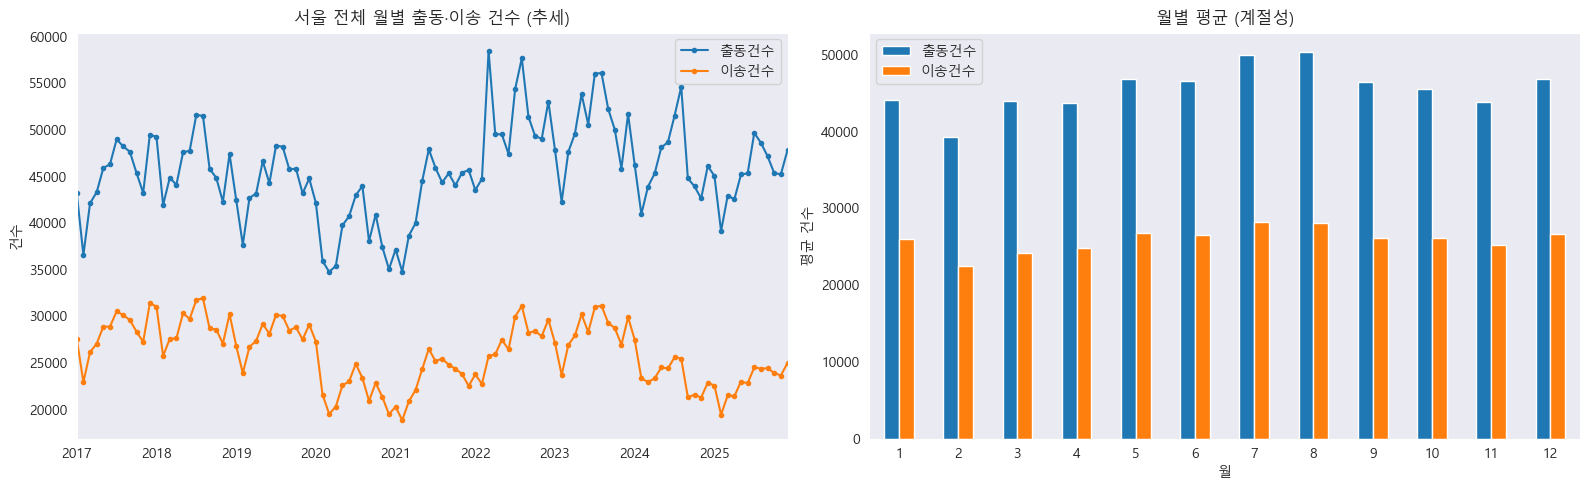

In [20]:
model_path = f"{ML_DIR}/ambulance_monthly.csv"

if os.path.exists(model_path):
    mdf = pd.read_csv(model_path, parse_dates=["ds"])
    seoul = mdf.groupby("ds")[["출동건수", "이송건수"]].sum()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    seoul.plot(ax=axes[0], marker="o", markersize=3)
    axes[0].set_title("서울 전체 월별 출동·이송 건수 (추세)")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("건수")

    by_month = seoul.groupby(seoul.index.month).mean()
    by_month.plot(kind="bar", ax=axes[1])
    axes[1].set_title("월별 평균 (계절성)")
    axes[1].set_xlabel("월")
    axes[1].set_ylabel("평균 건수")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print("[안내] ml_data/ambulance_monthly.csv가 없습니다. 3-2를 먼저 실행하세요.")

## 4-3. 자치구별 응급실 가용병상 (실시간, 참고용)

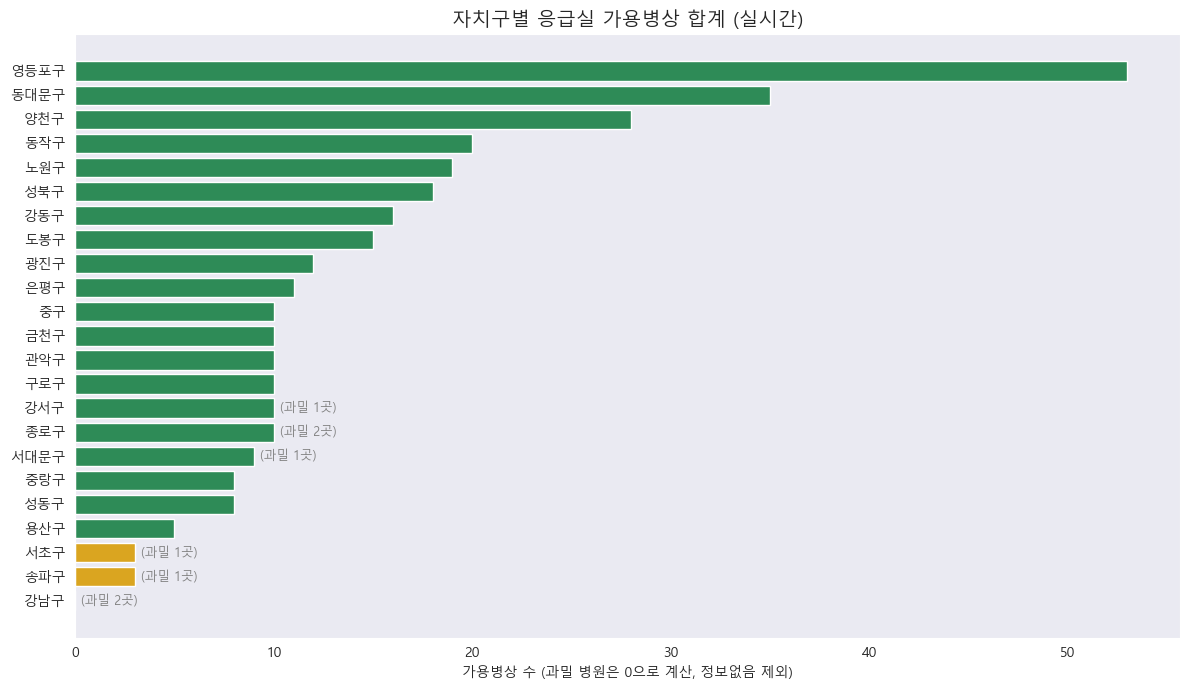

[범례] 진빨강: 과밀로 0개 / 빨강: 0개 / 주황: 1~3개 / 초록: 4개 이상
과밀 병원 8곳, 정보없음 병원 0곳 (갱신 지연 0곳 포함)


In [21]:
if os.path.exists(BEDS_PATH):
    beds_df = add_bed_status(pd.read_csv(BEDS_PATH))    # 갱신 지연 여부를 지금 시각 기준으로 다시 계산

    gu_beds = beds_df.groupby("District", as_index=False).agg(
        Available_Beds=("Available_Beds", "sum"),
        Overcrowded=("Is_Overcrowded", "sum"),
        Unknown=("Beds_Unknown", "sum"),
        Ffilled=("is_ffilled", "any"),
    ).sort_values("Available_Beds")

    def pick_color(beds, over):
        if over > 0 and beds == 0:
            return "darkred"
        if beds == 0:
            return "crimson"
        if beds <= 3:
            return "goldenrod"
        return "seagreen"

    colors = [pick_color(b, o) for b, o in zip(gu_beds["Available_Beds"], gu_beds["Overcrowded"])]

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(gu_beds["District"], gu_beds["Available_Beds"], color=colors)
    ax.set_title("자치구별 응급실 가용병상 합계 (실시간)", fontsize=14)
    ax.set_xlabel("가용병상 수 (과밀 병원은 0으로 계산, 정보없음 제외)")

    for i, row in enumerate(gu_beds.itertuples()):
        note = []
        if row.Overcrowded:
            note.append(f"과밀 {int(row.Overcrowded)}곳")
        if row.Unknown:
            note.append(f"정보없음 {int(row.Unknown)}곳")
        if row.Ffilled:
            note.append("직전값 대체")
        if note:
            ax.text(row.Available_Beds + 0.3, i, "(" + ", ".join(note) + ")",
                    va="center", fontsize=9, color="gray")

    plt.tight_layout()
    plt.show()

    print("[범례] 진빨강: 과밀로 0개 / 빨강: 0개 / 주황: 1~3개 / 초록: 4개 이상")
    print(f"과밀 병원 {int(beds_df['Is_Overcrowded'].sum())}곳, "
          f"정보없음 병원 {int(beds_df['Beds_Unknown'].sum())}곳 (갱신 지연 {int(beds_df['Is_Stale'].sum())}곳 포함)")
else:
    print("[안내] realtime_er_beds.csv가 없습니다. 3-3을 먼저 실행하세요.")

## 4-4. 병상 여유가 가장 적은 병원 TOP 10

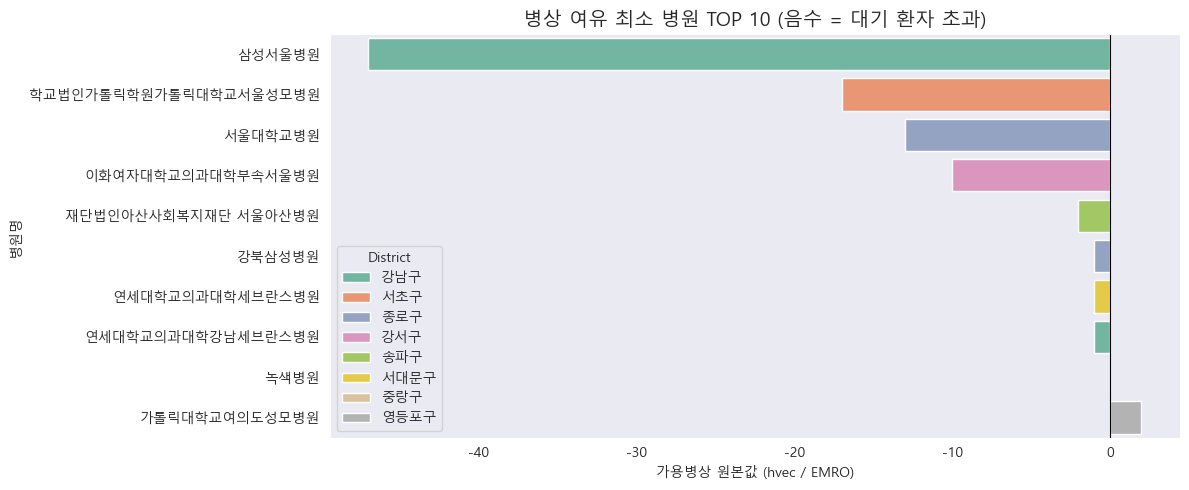

In [22]:
if os.path.exists(BEDS_PATH):
    known = beds_df[~beds_df["Beds_Unknown"]].sort_values("Beds_Raw").head(10)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=known, x="Beds_Raw", y="Hospital_Name", hue="District",
                dodge=False, palette="Set2", ax=ax)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("병상 여유 최소 병원 TOP 10 (음수 = 대기 환자 초과)", fontsize=14)
    ax.set_xlabel("가용병상 원본값 (hvec / EMRO)")
    ax.set_ylabel("병원명")
    plt.tight_layout()
    plt.show()

    if beds_df["Beds_Unknown"].any():
        print("--- 병상 정보를 알 수 없는 병원 ---")
        display(beds_df[beds_df["Beds_Unknown"]][["District", "Hospital_Name", "Updated_At", "Is_Stale"]])